# Re-Deriving the Branching Ratio 
...of eta -> mu+ mu- gamma, using the eta transition form factor from the 2025 BESIII measurement (arXiv:2506.08576), compared against the 1980 and 2016 (NA60, 1608.07898) measurements.


**Author**: Michael Peters  

### Define constants and data

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from tabulate import tabulate
import math

from plot_style import COLORS, style_axes, apply_font
apply_font()

# Constants
ALPHA = 1. / 137. # m_Z mass scale
M_ETA = 0.547862  # from pdg
M_MU = .1056583745  # from pdg
BR_ETA2GG =.3936  # from pdg
prefactor = (2 * ALPHA) / (3 * np.pi) * BR_ETA2GG

# BESIII/PDG normalization-channel branching ratio: BR(eta -> mu+ mu- gamma) =
# (2.98 +/- 0.13)e-4, the PDG average now dominated by the 2025 BESIII
# measurement (arXiv:2506.08576).
BR0, DBR0 = 2.98e-4, 0.13e-4

In [2]:
# BESIII (arXiv:2506.08576): digitized F^2 vs. dimuon mass data.
x_mass = np.array([0.21488865827764417, 0.22092317156227345, 0.2269576848469027, 0.23299925108782887, 0.23898435813897587, 0.2449694651901229, 0.25095457224126994, 0.2569396857541268, 0.2630377176465419, 0.2689098998564208, 0.2750079317488359, 0.28099303879998294, 0.2869781523128398, 0.292963252902277, 0.298948359953424, 0.3050464047692588, 0.3110315118204058, 0.31701661887155286, 0.3230017259226998, 0.3289868329738469, 0.33497194002499386, 0.3409570470761409, 0.34705507896855603, 0.353040186019703, 0.35902529307085007, 0.36501040012199704, 0.3709955071731441, 0.3769806271477108, 0.3829657341988578, 0.3889508412500048, 0.39504887314241993, 0.4010339672701473, 0.407019087244714, 0.41300420721928066, 0.41898931427042774, 0.4249744213215747, 0.4310724532139898, 0.43705756026513687, 0.44304266731628383, 0.4490277743674309, 0.4550128814185779, 0.4609979884697249, 0.4669830955208719, 0.47296820257201894, 0.4910364614901478])  # dimuon mass, GeV/c^2
x = x_mass ** 2  # q^2 = m^2_mumu, GeV^2/c^4
y = np.array([0.9995637937646726, 0.7454942876677657, 0.6515984337029066, 0.575145240175579, 0.9007267531219085, 1.1100290972713291, 0.7379361297195906, 0.5984012336199769, 0.8356103973043041, 0.7007265934368927, 0.8821221180514063, 0.8077035777693973, 1.3937499817027585, 0.7286336791134926, 0.7239825868812904, 0.7007265934368927, 1.1565408180184313, 1.091424462200827, 0.47747097259086546, 1.5844476907816767, 1.1751454530889336, 1.2449129011387403, 1.0635173765242267, 1.1844476375533382, 0.8309593050721018, 0.9100289375863131, 0.9053778453541108, 1.6170058686904791, 2.4774711056617122, 1.2542150856031449, 1.4356106102176587, 1.6077034180843812, 0.7053779518107881, 1.5844476907816767, 1.148401140470384, 1.1018896858649752, 1.7018896326366364, 0.5018897390933137, 1.7344478105454388, 1.3623548429937, 2.4553780183462113, 1.925145519624357, 1.2925873949438933, 1.5111919235577183, 3.971657240371459])
y_plus = np.array([1.2094473913722719, 0.9001449673803434, 0.7841566914542168, 0.6998547132496247, 1.0499997737795606, 1.2802325652572777, 0.88691825750646, 0.7286336791134926, 0.9972382476485715, 0.8437500748523512, 1.0547961793763077, 0.9780520929781975, 1.611191737258533, 0.9013080065800871, 0.8965116009833403, 0.8821218519097129, 1.3905522892576963, 1.3234012801947732, 0.6374998436417552, 1.884592977532052, 1.4529068927238724, 1.54404072819561, 1.361773057252135, 1.5056684188548615, 1.1075582377906832, 1.2178776956494084, 1.2274710391262889, 2.076453459669021, 3.07412791355292, 1.7023255727302704, 1.9421511754014813, 2.181976778072692, 1.121947454580924, 2.2347383042036815, 1.7311045385941384, 1.742877848680882, 2.5670058287692252, 0.9972382476485715, 2.7370639833906294, 2.3271802260980143, 3.883866410709329, 3.286482636782858, 2.5931686217879024, 3.033575637602308, 7.957413403481187])  # upper error bars
yerr = y_plus - y  # y errors

# Lambda_eta^-2 (eta -> mu+ mu- gamma) = 1.645 +/- 0.343 (GeV/c^2)^-2, reported
# directly by BESIII. Propagated through Lambda = (Lambda^-2)^(-1/2) to get
# [value, uncertainty] below.
LAMBDA2INV, DLAMBDA2INV = 1.645, 0.343  # (GeV/c^2)^-2
LAMBDA0 = [LAMBDA2INV ** -0.5, 0.5 * LAMBDA2INV ** -1.5 * DLAMBDA2INV]  # [value, uncertainty]
print("Lambda_eta = {:.3f} +/- {:.3f} GeV/c^2".format(*LAMBDA0))
K0 = 0.7181684554493444  # BESIII-reported K

Lambda_eta = 0.780 +/- 0.081 GeV/c^2


### Define FormFactor class

In [3]:
class FormFactor:
    def __init__(self, alpha=ALPHA, m_eta=M_ETA, m_mu=M_MU, br_eta2gg=BR_ETA2GG, Lambda0=LAMBDA0, K0=K0):
        self.alpha = alpha
        self.m_eta = m_eta
        self.m_mu = m_mu
        self.br_eta2gg = br_eta2gg
        self.q2_min = (2 * self.m_mu)**2
        self.q2_max = self.m_eta**2
        self.prefactor = (2 * self.alpha) / (3 * np.pi) * self.br_eta2gg
        self.Lambda0 = Lambda0
        self.K0 = K0

    # =============================================================================

    def F(self, x, Lambda):
        """Form factor of the eta meson in the pole approximation (paper Eq. 5).

        The pole model is:
            F(q^2; 0) = (1 - q^2/Λ^2)^(-1)

        Args:
            x (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ

        Returns:
            float: F(q^2; 0)
        """
        return (1.0 - x / Lambda**2) ** (-1)

    # =============================================================================

    def F2(self, x, Lambda, K=1.0):
        """Squared form factor F^2(q^2; 0).

        Note: experimental points for F^2 are often fit with an extra overall
        normalization factor:
            F^2(q^2; 0) = K * (1 - q^2/Λ^2)^(-2)
        where K absorbs normalization uncertainty.

        Args:
            x (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ
            K (float): overall normalization factor for F^2 (default 1)

        Returns:
            float: F^2(q^2; 0) (optionally scaled by K)
        """
        return K * (1.0 - x / (Lambda**2))**(-2)

    # =============================================================================

    def fit(self, x, y, yerr=None, fit_Lambda=True, fit_K=True):
        """Fit wrapper for scipy's curve_fit() which allows for choice of free
        parameters.

        Args:
            x (list): x values from data in plot
            y (list): y values from data in plot
            yerr (np.array, optional): y error values from data in plot. Defaults
                to None.
            fit_Lambda (bool, optional): _description_. Defaults to True.
            fit_K (bool, optional): _description_. Defaults to True.

        Returns:
            dict (string, float): Lambda and K fit results, including errors.
        """
        # For all fixed values.
        if not fit_Lambda and not fit_K:
            return {'Lambda': self.Lambda0[0], 
                    'Lambda_err': self.Lambda0[1],
                    'K': K0, 
                    'K_err': 0.0}
        if fit_Lambda and fit_K:
            def fnc(x, Lambda, K): return self.F2(x, Lambda, K)
            bounds = ([0.0, 0.0], [np.inf, np.inf])
        elif fit_Lambda and not fit_K:
            def fnc(x, Lambda): return self.F2(x, Lambda, K0)
            bounds = ([0.0], [np.inf])
        elif not fit_Lambda and fit_K:
            def fnc(x, K): return self.F2(x, self.Lambda0[0], K)
            bounds = ([0.0], [np.inf])

        # Ensure all data is numpy array
        popt, pcov = curve_fit(fnc, np.array(x), np.array(y), 
                               sigma=np.array(yerr), absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))

        # Convert to float values
        popt = [float(v) for v in popt]
        perr = [float(v) for v in perr]

        result = {}
        idx = 0
        if fit_Lambda:
            result['Lambda'] = popt[idx]
            result['Lambda_err'] = perr[idx]
            idx += 1
        else:
            result['Lambda'] = self.Lambda0[0]
            result['Lambda_err'] = self.Lambda0[1]
        if fit_K:
            result['K'] = popt[idx]
            result['K_err'] = perr[idx]
            idx += 1
        else:
            result['K'] = K0
            result['K_err'] = 0.0

        return result

    # =============================================================================

    def integrand(self, q2, Lambda):
        """Integrand of the eta form factor integral over q2. Eqn. 4 from the
        paper.

        Args:
            q2 (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ

        Returns:
            float: integrand value
        """
        # Kinematic limits
        if q2 < self.q2_min or q2 > self.q2_max: return 0.0

        term1 = (1 - q2 / self.m_eta**2)**3
        term2 = (1 + 2 * self.m_mu**2 / q2)
        term3 = np.sqrt(1 - 4 * self.m_mu**2 / q2)
        term4 = abs(self.F(q2, Lambda))**2
        return term1 * term2 * term3 * term4 / q2

    # =============================================================================

    def integrate(self, Lambda, bounds=None):
        """Calculate form factor integral.

        Args:
            Lambda (float): Parameter value
            bounds (list (float, float)): (Optional) Custom bounds of integration.
                Default bounds of integration are [self.q2_min, self.q2_max].

        Returns:
            (float, float): integral value and its numerical uncertainty
        """
        if bounds is None: bounds = [self.q2_min, self.q2_max]

        # Pass points of possible divergence into `quad`, which then handles any
        # difficulties in convergence.
        points = []
        if bounds[0] < Lambda**2 < bounds[1]: points.append(Lambda**2)

        def integrand_at_lambda(q2):
            return self.integrand(q2, Lambda)

        return integrate.quad(
            integrand_at_lambda,
            bounds[0],
            bounds[1],
            points=points,
        )

    # =============================================================================

    def branching_ratio(self, Lambda, bounds=None):
        """Calculate the branching ratio.

        Args:
            Lambda (float): Lambda parameter value

        Returns:
            list (float, float): List of branching ratio and its uncertainty value
        """
        int_val, _ = self.integrate(Lambda, bounds=bounds)
        return self.prefactor * int_val

### Run fit

In [4]:
ff = FormFactor()

In [5]:
fits = []
fit_Lambda = [True, False]
fit_K = [True, False]
table = []

for i in range(2):
    for j in range(2):
        fit = {'fit_Lambda': fit_Lambda[i], 'fit_K': fit_K[j]}
        fit.update(ff.fit(x, y, yerr, fit_Lambda=fit_Lambda[i], fit_K=fit_K[j]))
        fits.append(fit)

for fit in fits:
    table.append((fit['fit_Lambda'], fit['fit_K'], 
                  f"{fit['Lambda']:.2f}", f"{fit['Lambda_err']:.2f}", 
                  f"{fit['K']:.2f}", f"{fit['K_err']:.2f}"))

headers = ['fit Λ', 'fit K', 'Λ', 'ΔΛ', 'K', 'ΔK']
print(tabulate(table, headers, tablefmt="github"))

| fit Λ   | fit K   |    Λ |   ΔΛ |    K |   ΔK |
|---------|---------|------|------|------|------|
| True    | True    | 0.76 | 0.08 | 0.62 | 0.05 |
| True    | False   | 0.95 | 0.08 | 0.72 | 0    |
| False   | True    | 0.78 | 0.08 | 0.63 | 0.03 |
| False   | False   | 0.78 | 0.08 | 0.72 | 0    |


In [6]:
table = []
for fit in fits:
    int_val, int_err = ff.integrate(fit['Lambda'])
    br = ff.branching_ratio(fit['Lambda'])

    print(f"fit Lambda = {fit['fit_Lambda']}, fit K = {fit['fit_K']}:")
    print(f"integral = {int_val:.3f} ± {int_err:.0e}")
    print(f"BR = {br * 1e4:.2f}e-4\n")

    table.append((
        str(fit['fit_Lambda']),
        str(fit['fit_K']),
        f"{br * 1e4:.2f}e-4"
    ))

headers = ['fit Λ', 'fit K', 'BR']
print(tabulate(table, headers, tablefmt="github"))

fit Lambda = True, fit K = True:
integral = 0.505 ± 7e-09
BR = 3.08e-4

fit Lambda = True, fit K = False:
integral = 0.440 ± 7e-09
BR = 2.68e-4

fit Lambda = False, fit K = True:
integral = 0.496 ± 7e-09
BR = 3.02e-4

fit Lambda = False, fit K = False:
integral = 0.496 ± 7e-09
BR = 3.02e-4

| fit Λ   | fit K   |       BR |
|---------|---------|----------|
| True    | True    | 0.000308 |
| True    | False   | 0.000268 |
| False   | True    | 0.000302 |
| False   | False   | 0.000302 |


### Plot fits

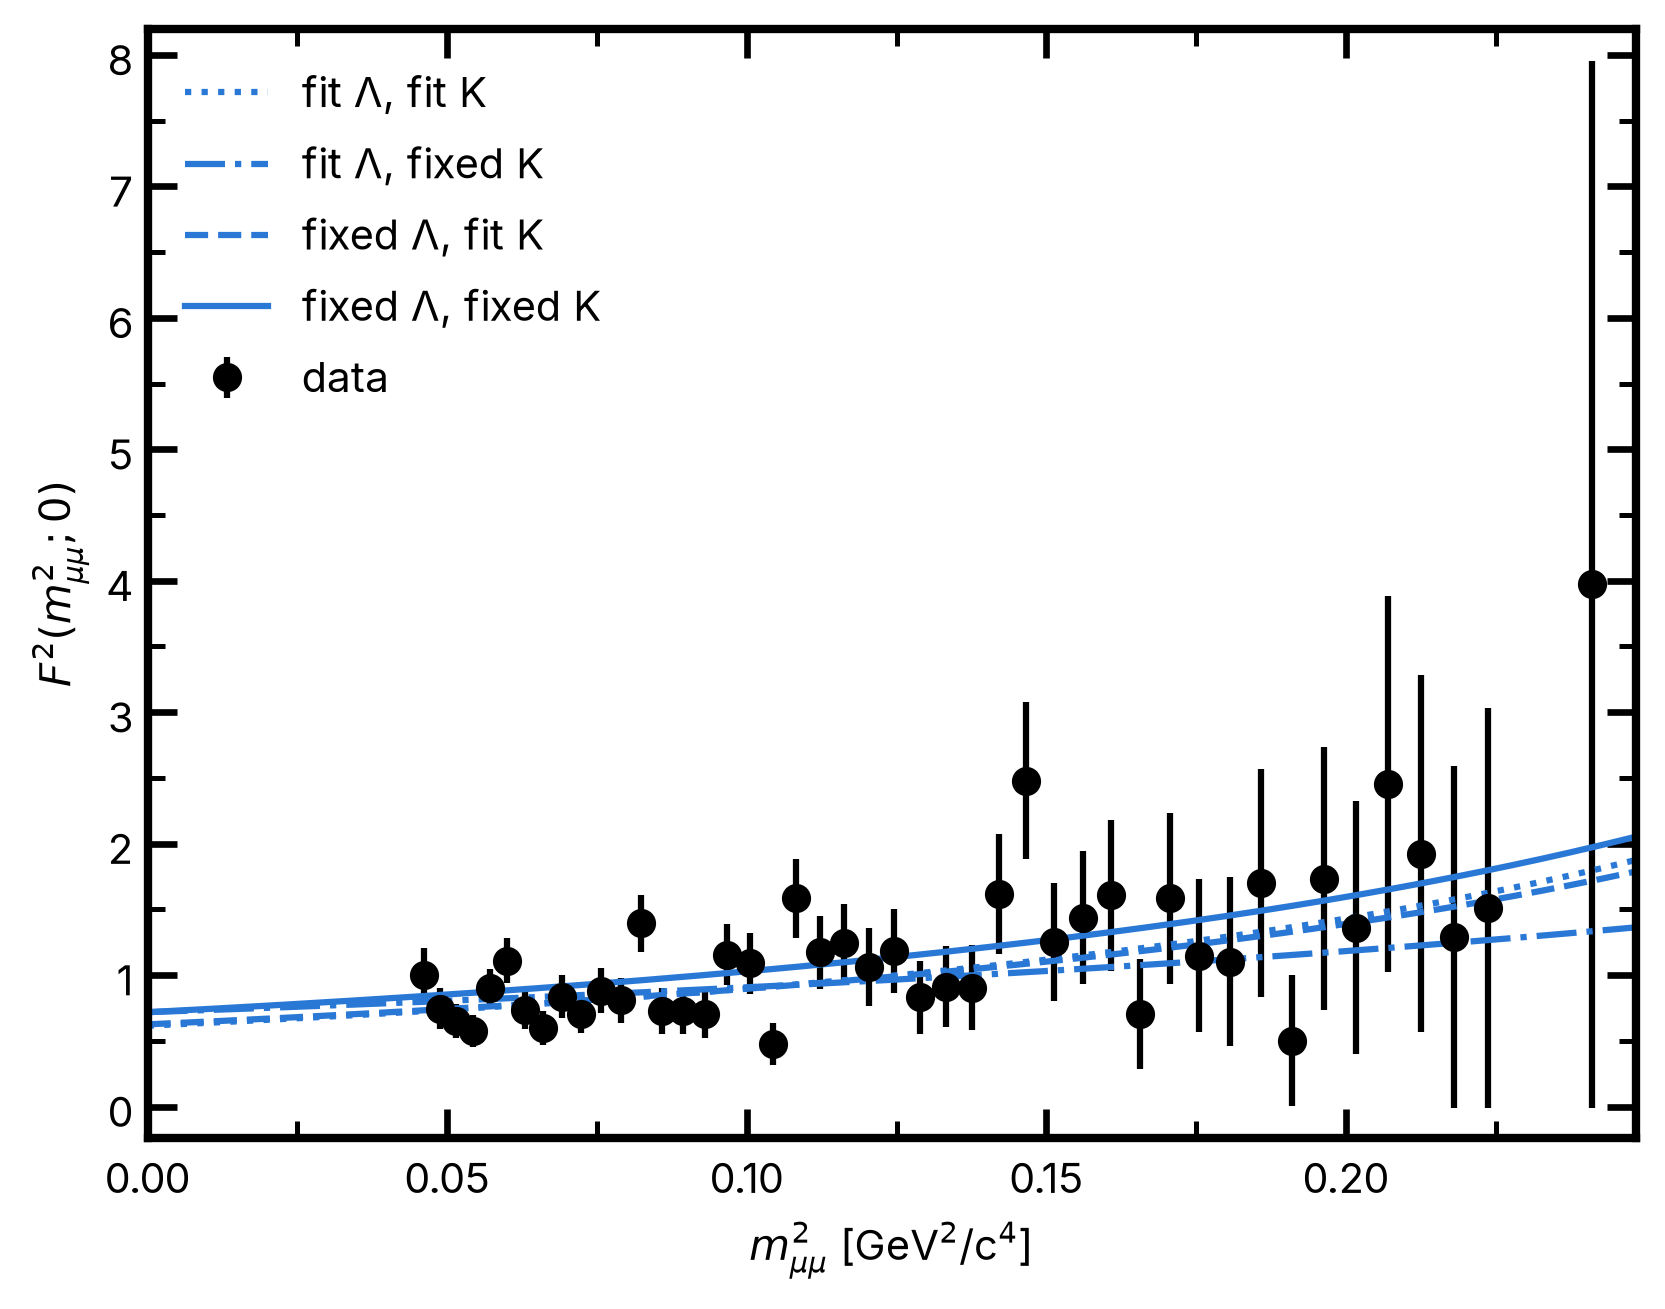

In [7]:
# Plot data with error bars and the fitted curve
plt.errorbar(x, y, yerr=yerr, fmt='o', color=COLORS['data'], label='data')

# Left edge pinned to 0 (physical q^2=0); a little padding added on the right
# only, so the rightmost data point/marker isn't clipped by the axis edge.
x_pad = 0.03 * x.max()
xx = np.linspace(0, x.max() + x_pad, 400)
curve0 = ff.F2(xx, fits[0]['Lambda'], fits[0]['K'])
curve1 = ff.F2(xx, fits[1]['Lambda'], fits[1]['K'])
curve2 = ff.F2(xx, fits[2]['Lambda'], fits[2]['K'])
curve3 = ff.F2(xx, fits[3]['Lambda'], fits[3]['K'])
plt.plot(xx, curve0, ':', color=COLORS['primary'], label="fit Λ, fit K")
plt.plot(xx, curve1, '-.', color=COLORS['primary'], label="fit Λ, fixed K")
plt.plot(xx, curve2, '--', color=COLORS['primary'], label="fixed Λ, fit K")
plt.plot(xx, curve3, '-', color=COLORS['primary'], label="fixed Λ, fixed K")
plt.legend(frameon=False, loc='upper left')
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")

y_max = max(np.max(y + yerr), curve0.max(), curve1.max(), curve2.max(), curve3.max())
y_pad = 0.03 * y_max
ax = plt.gca()
ax.set_xlim(0, x.max() + x_pad)
ax.set_ylim(-y_pad, y_max + y_pad)
style_axes(ax, n_minor=2, integer_y=True)
plt.show()


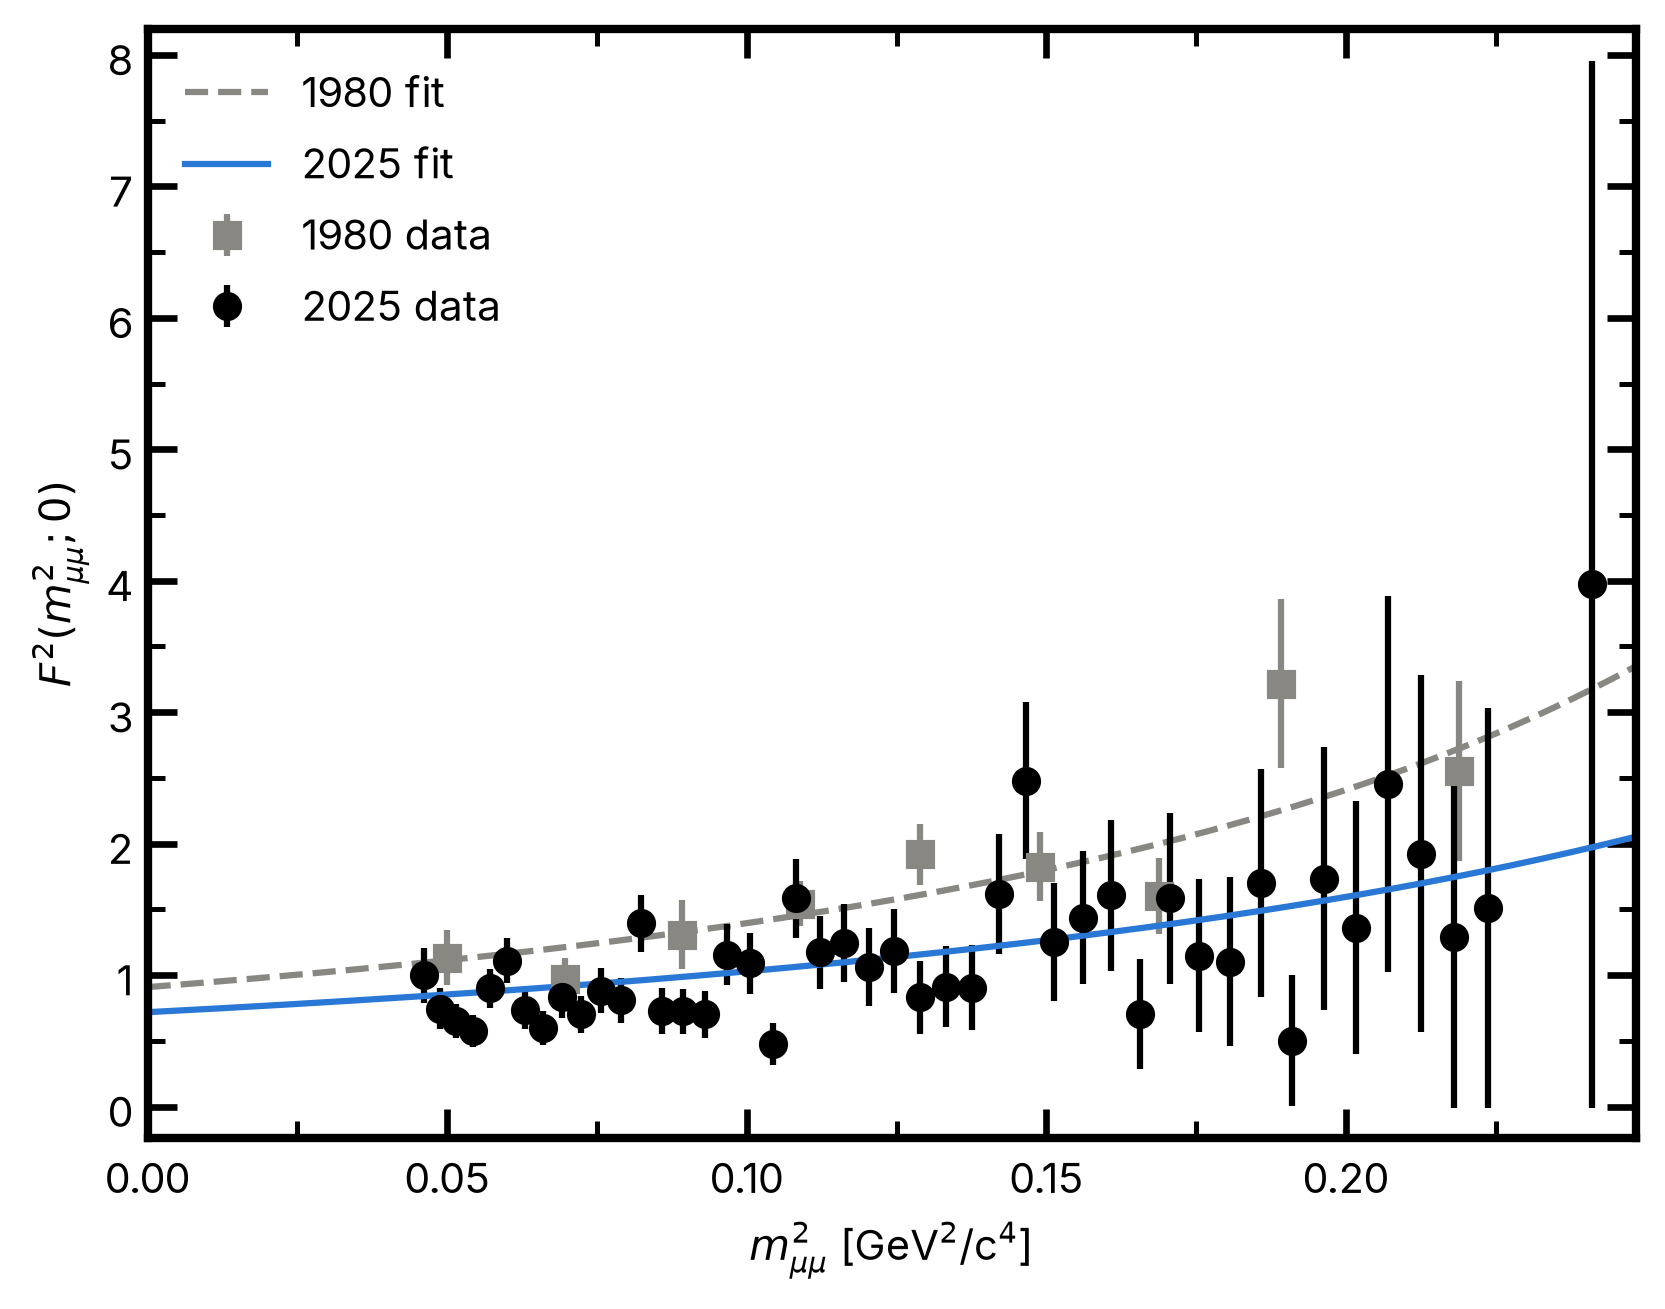

In [8]:
# Compare 1980 paper data/fit against the 2025 (BESIII) data/fit
x_old = np.array([0.04994, 0.06962, 0.08918, 0.10887, 0.12889, 0.14895, 0.16888,
                    0.18911, 0.2188])  # mass^2, GeV^2/c^4
y_old = np.array([1.13117, 0.96908, 1.30802, 1.54427, 1.91811, 1.82588, 1.60247,
                    3.21721, 2.55531])
ybar_old = [1.34043, 1.13093, 1.57283, 1.71686, 2.14894, 2.08674, 1.89034, 3.86088,
             3.23895]  # upper error bars
yerr_old = np.subtract(ybar_old, y_old)
Lambda_old, K_old = 0.72, 0.9089376019880376  # from 1980 paper

# Left edge pinned to 0 (physical q^2=0); a little padding added on the right
# only, so the rightmost data point/marker isn't clipped by the axis edge.
x_max = max(x.max(), x_old.max())
x_pad = 0.03 * x_max
xx = np.linspace(0, x_max + x_pad, 400)
old_fit_curve = ff.F2(xx, Lambda_old, K_old)
# Use the fixed-Lambda, fixed-K entry from the 2x2 fit table (fits[3]) so the
# "2025 fit" shown here always matches LAMBDA0/K0, not a re-fit.
new_fit_curve = ff.F2(xx, fits[3]['Lambda'], fits[3]['K'])

plt.errorbar(x_old, y_old, yerr=yerr_old, fmt='s', color=COLORS['reference'], label='1980 data')
plt.plot(xx, old_fit_curve, '--', color=COLORS['reference'], label='1980 fit')

plt.errorbar(x, y, yerr=yerr, fmt='o', color=COLORS['data'], label='2025 data')
plt.plot(xx, new_fit_curve, '-', color=COLORS['primary'], label='2025 fit')

plt.legend(frameon=False, loc='upper left')
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")

y_max = max(np.max(y + yerr), np.max(y_old + yerr_old), old_fit_curve.max(), new_fit_curve.max())
y_pad = 0.03 * y_max
ax = plt.gca()
ax.set_xlim(0, x_max + x_pad)
ax.set_ylim(-y_pad, y_max + y_pad)
style_axes(ax, n_minor=2, integer_y=True)
plt.show()


The four fits span a wider range than the 2016 ones did: Λ runs from 0.76±0.08 (both Λ and K free) up to 0.95±0.08 (Λ free, K fixed at the BESIII value), while holding Λ fixed at the BESIII-reported value (0.78±0.08) pulls the free K down to 0.63±0.03, notably below the reported K0=0.718. This spread reflects the larger point-to-point uncertainties in this sample.

## Uncertainty Propagation

### Method I: Numerical Propagation

Here, we sample `n` values of Λ normally distributed about its mean, with standard deviation $\sigma_\Lambda$.

For each Λ sampled, we compute the branching ratio. We then collect all these branching ratio values and find their mean and standard deviation.

In [9]:
ff = FormFactor()
n = 10000
Lambdas = np.random.normal(LAMBDA0[0], LAMBDA0[1], n)

br_values = []
for Lambda in Lambdas:
    int_val, int_err = ff.integrate(Lambda)
    br = ff.branching_ratio(Lambda)
    br_values.append(br)

br_values = np.array(br_values)
br_mean = np.mean(br_values)
br_unc  = math.sqrt(np.std(br_values)**2 + int_err**2)
print(f"BR = ({br_mean * 10000.:.2f} ± {br_unc * 10000.:.2f})e-4")

/tmp/ipykernel_68694/3282013541.py:156: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return integrate.quad(


BR = (3.10 ± 0.33)e-4


The result is in agreement with the measured BR0 = (2.98 ± 0.13)e-4 (about 0.3σ higher).

---

### Method II: $\pm\sigma$ Difference
Calculate branching ratio from $\Lambda+\sigma_\Lambda$ and $\Lambda-\sigma_\Lambda$, find the difference, then divide by 2. This method is quick and works well if the lambda uncertainty is smooth and approximately linear.

In [10]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)

br_p = ff_p.branching_ratio(Lambda_p)
br_m = ff_m.branching_ratio(Lambda_m)

# Print values
print(f"BR+ = {br_p * 10000.:.2f}e-4")
print(f"BR- = {br_m * 10000.:.2f}e-4\n")

# Find difference
br_unc = abs((br_p - br_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

BR+ = 2.83e-4
BR- = 3.34e-4

BR uncertainty = 0.26e-4



Phil also mentioned a slightly different method of doing this. I'll try it just to see if there's any difference.

In [11]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)
ff = FormFactor(Lambda0=LAMBDA0[0])

br_unc_p = ff_p.branching_ratio(Lambda_p) - ff.branching_ratio(LAMBDA0[0])
br_unc_m = ff.branching_ratio(LAMBDA0[0]) - ff_m.branching_ratio(Lambda_m)

# Print values
print(f"ΔBR+ = {br_unc_p * 10000.:.2f}e-4")
print(f"ΔBR- = {br_unc_m * 10000.:.2f}e-4\n")

# Find average
br_unc = abs((br_unc_p + br_unc_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

ΔBR+ = -0.20e-4
ΔBR- = -0.31e-4

BR uncertainty = 0.26e-4



The two methods are reasonably close (0.32 vs 0.26 e-4), though not as tight as for the 2016 data -- the larger relative ΔΛ here makes Method II's linear approximation less exact.

## Form Factor: 2025 vs. 2016 (NA60)

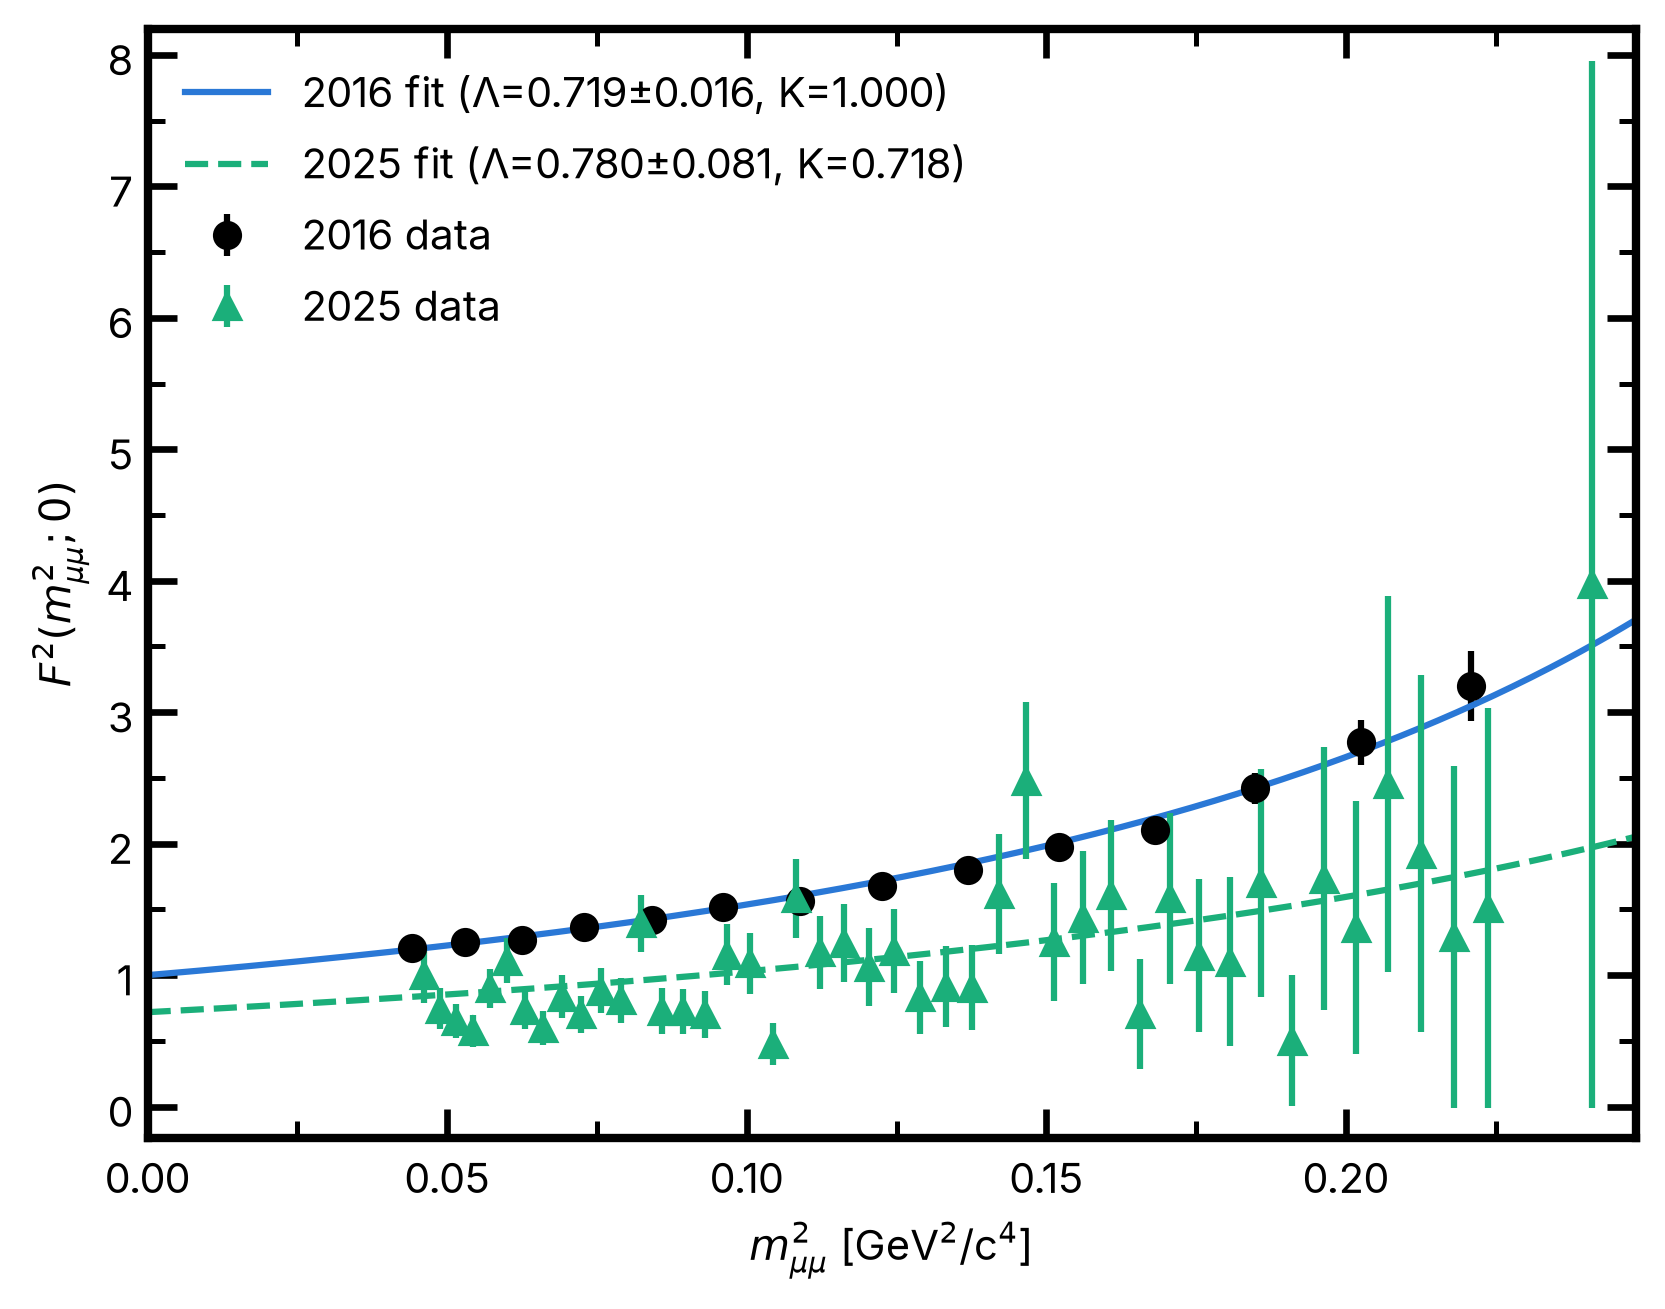

In [12]:
# NA60 (1608.07898) reference: digitized F^2 vs. dimuon mass, and NA60's own
# reported pole-fit result. Hardcoded here since this file's primary data is
# the 2025 BESIII sample.
x_mass_2016 = np.array([0.21, 0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35, 0.37,
                    0.39, 0.41, 0.43, 0.45, 0.47])  # dimuon mass, GeV/c^2
x_2016 = x_mass_2016 ** 2
y_2016 = np.array([1.208, 1.250, 1.264, 1.367, 1.423, 1.522, 1.565, 1.677,
              1.796, 1.978, 2.105, 2.42, 2.77, 3.20])
ybar_2016 = [1.24406, 1.27283, 1.28860, 1.39518, 1.45346, 1.55785, 1.60663,
        1.72533, 1.85418, 2.04970, 2.19508, 2.53705, 2.94464, 3.46401]
yerr_2016 = np.subtract(ybar_2016, y_2016)
Lambda_2016, dLambda_2016, K_2016 = 0.71907, 0.01554, 1.0  # NA60's own shape-fit result

# Left edge pinned to 0 (physical q^2=0); a little padding added on the right
# only, so the rightmost data point/marker isn't clipped by the axis edge.
x_max = max(x.max(), x_2016.max())
x_pad = 0.03 * x_max
xx = np.linspace(0, x_max + x_pad, 400)
curve_2016 = ff.F2(xx, Lambda_2016, K_2016)
curve_2025 = ff.F2(xx, LAMBDA0[0], K0)

plt.errorbar(x_2016, y_2016, yerr=yerr_2016, fmt='o', color=COLORS['data'], label='2016 data')
plt.plot(xx, curve_2016, '-', color=COLORS['primary'],
         label=f'2016 fit (Λ={Lambda_2016:.3f}±{dLambda_2016:.3f}, K={K_2016:.3f})')

plt.errorbar(x, y, yerr=yerr, fmt='^', color=COLORS['secondary'], label='2025 data')
plt.plot(xx, curve_2025, '--', color=COLORS['secondary'],
         label=f'2025 fit (Λ={LAMBDA0[0]:.3f}±{LAMBDA0[1]:.3f}, K={K0:.3f})')

plt.legend(frameon=False, loc='upper left')
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")

y_max = max(np.max(y_2016 + yerr_2016), np.max(y + yerr), curve_2016.max(), curve_2025.max())
y_pad = 0.03 * y_max
ax = plt.gca()
ax.set_xlim(0, x_max + x_pad)
ax.set_ylim(-y_pad, y_max + y_pad)
style_axes(ax, n_minor=2, integer_y=True)
plt.show()


| Source                    |   Lambda [GeV/c^2] | dLambda   |   Lambda^-2 [(GeV/c^2)^-2] | dLambda^-2   |
|---------------------------|--------------------|-----------|----------------------------|--------------|
| 1980                      |             0.72   | -         |                      1.929 | -            |
| 2016 (NA60, 1608.07898)   |             0.7191 | 0.0155    |                      1.934 | 0.0836       |
| 2025 (BESIII, 2506.08576) |             0.7797 | 0.0813    |                      1.645 | 0.3430       |

2025 vs. 2016 (NA60): +0.0606 GeV/c^2 (0.7 sigma)


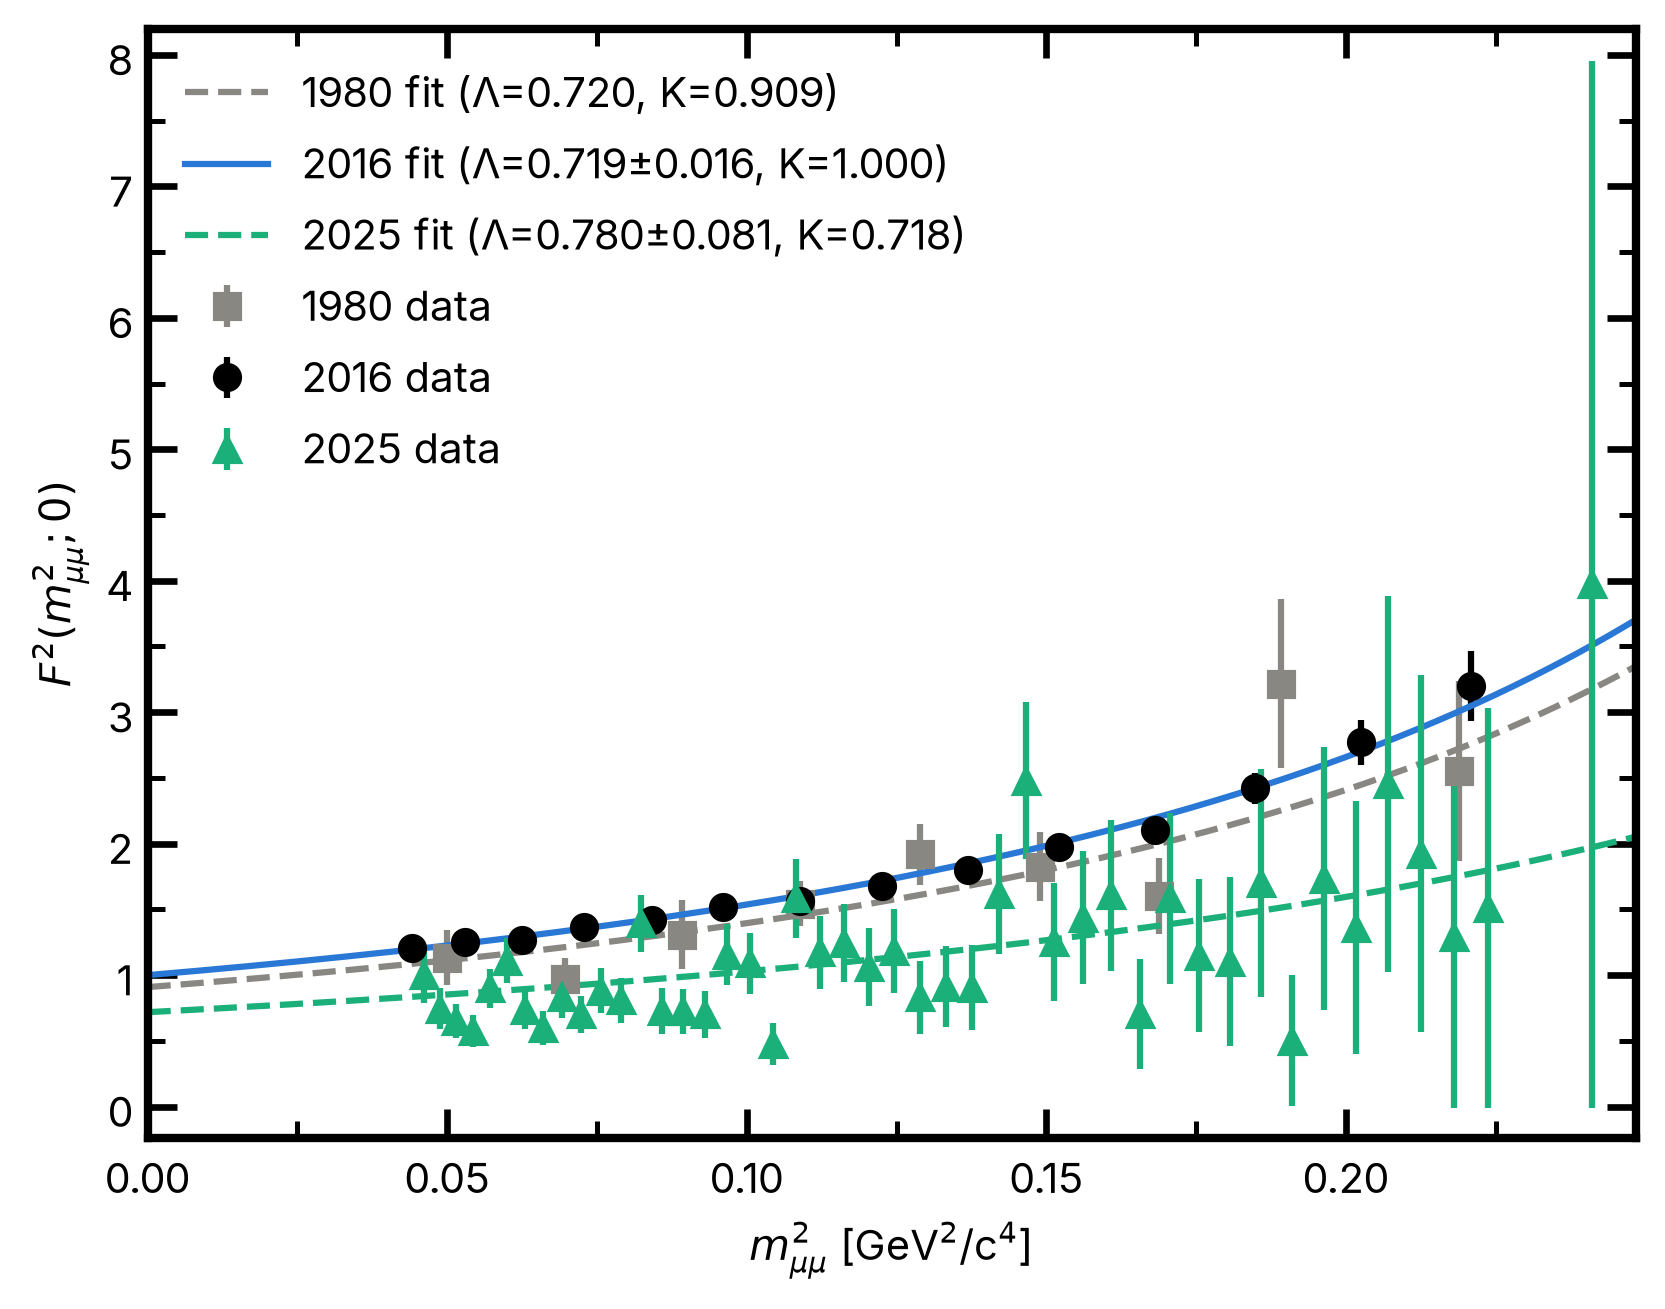

In [13]:
# 1980 reference: digitized F^2 vs. mass^2, and the paper's own pole-fit
# result. Hardcoded here since this file's primary data is the 2025 BESIII
# sample; the 2016 (NA60) reference from the cell above is reused as-is.
x_1980 = np.array([0.04994, 0.06962, 0.08918, 0.10887, 0.12889, 0.14895, 0.16888,
                    0.18911, 0.2188])  # mass^2, GeV^2/c^4
y_1980 = np.array([1.13117, 0.96908, 1.30802, 1.54427, 1.91811, 1.82588, 1.60247,
                    3.21721, 2.55531])
ybar_1980 = [1.34043, 1.13093, 1.57283, 1.71686, 2.14894, 2.08674, 1.89034, 3.86088,
             3.23895]  # upper error bars
yerr_1980 = np.subtract(ybar_1980, y_1980)
Lambda_1980, K_1980 = 0.72, 0.9089376019880376  # from 1980 paper

# Lambda by source: 1980 (fixed, no reported uncertainty), 2016 NA60
# (1608.07898), and 2025 BESIII (2506.08576, this file's primary fit).
table = [
    ['1980', f'{Lambda_1980:.4f}', '-', f'{Lambda_1980**-2:.4f}', '-'],
    ['2016 (NA60, 1608.07898)', f'{Lambda_2016:.4f}', f'{dLambda_2016:.4f}',
     f'{Lambda_2016**-2:.4f}', f'{2*dLambda_2016/Lambda_2016**3:.4f}'],
    ['2025 (BESIII, 2506.08576)', f'{LAMBDA0[0]:.4f}', f'{LAMBDA0[1]:.4f}',
     f'{LAMBDA0[0]**-2:.4f}', f'{2*LAMBDA0[1]/LAMBDA0[0]**3:.4f}'],
]
headers = ['Source', 'Lambda [GeV/c^2]', 'dLambda', 'Lambda^-2 [(GeV/c^2)^-2]', 'dLambda^-2']
print(tabulate(table, headers, tablefmt="github"))

tension_2016 = abs(LAMBDA0[0] - Lambda_2016) / np.sqrt(LAMBDA0[1]**2 + dLambda_2016**2)
print(f"\n2025 vs. 2016 (NA60): {LAMBDA0[0] - Lambda_2016:+.4f} GeV/c^2 ({tension_2016:.1f} sigma)")

# Left edge pinned to 0 (physical q^2=0); a little padding added on the right
# only, so the rightmost data point/marker isn't clipped by the axis edge.
x_max = max(x.max(), x_2016.max(), x_1980.max())
x_pad = 0.03 * x_max
xx = np.linspace(0, x_max + x_pad, 400)
curve_1980 = ff.F2(xx, Lambda_1980, K_1980)
curve_2016 = ff.F2(xx, Lambda_2016, K_2016)
curve_2025 = ff.F2(xx, LAMBDA0[0], K0)

plt.errorbar(x_1980, y_1980, yerr=yerr_1980, fmt='s', color=COLORS['reference'], label='1980 data')
plt.plot(xx, curve_1980, '--', color=COLORS['reference'],
         label=f'1980 fit (Λ={Lambda_1980:.3f}, K={K_1980:.3f})')

plt.errorbar(x_2016, y_2016, yerr=yerr_2016, fmt='o', color=COLORS['data'], label='2016 data')
plt.plot(xx, curve_2016, '-', color=COLORS['primary'],
         label=f'2016 fit (Λ={Lambda_2016:.3f}±{dLambda_2016:.3f}, K={K_2016:.3f})')

plt.errorbar(x, y, yerr=yerr, fmt='^', color=COLORS['secondary'], label='2025 data')
plt.plot(xx, curve_2025, '--', color=COLORS['secondary'],
         label=f'2025 fit (Λ={LAMBDA0[0]:.3f}±{LAMBDA0[1]:.3f}, K={K0:.3f})')

plt.legend(frameon=False, loc='upper left')
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")

y_max = max(np.max(y_1980 + yerr_1980), np.max(y_2016 + yerr_2016), np.max(y + yerr),
            curve_1980.max(), curve_2016.max(), curve_2025.max())
y_pad = 0.03 * y_max
ax = plt.gca()
ax.set_xlim(0, x_max + x_pad)
ax.set_ylim(-y_pad, y_max + y_pad)
style_axes(ax, n_minor=2, integer_y=True)
plt.show()


### Plot of (br uncertainty / br) vs q2 max

Optimal q2_max = 0.0652 GeV^2/c^4
  syst (Lambda) = 4.356%, stat (yield) = 2.686%, total = 5.118%
  retained signal ~ 60,412 of 223,295 (27.1%)
  BR = 0.818e-4, total unc = 0.042e-4
|   q2_max | syst (Lambda)   | stat (yield)   | total   |   N_retained |
|----------|-----------------|----------------|---------|--------------|
|   0.0455 | 3.450%          | 22.850%        | 23.109% |          835 |
|   0.0626 | 4.245%          | 2.888%         | 5.134%  |       52,269 |
|   0.0797 | 4.954%          | 2.072%         | 5.370%  |      101,540 |
|   0.0968 | 5.593%          | 1.773%         | 5.867%  |      138,626 |
|   0.1139 | 6.167%          | 1.622%         | 6.376%  |      165,614 |
|   0.131  | 6.676%          | 1.535%         | 6.851%  |      184,975 |
|   0.1481 | 7.121%          | 1.481%         | 7.273%  |      198,657 |
|   0.1651 | 7.498%          | 1.447%         | 7.637%  |      208,124 |
|   0.1822 | 7.807%          | 1.426%         | 7.937%  |      214,475 |
|   0.1993 | 8.

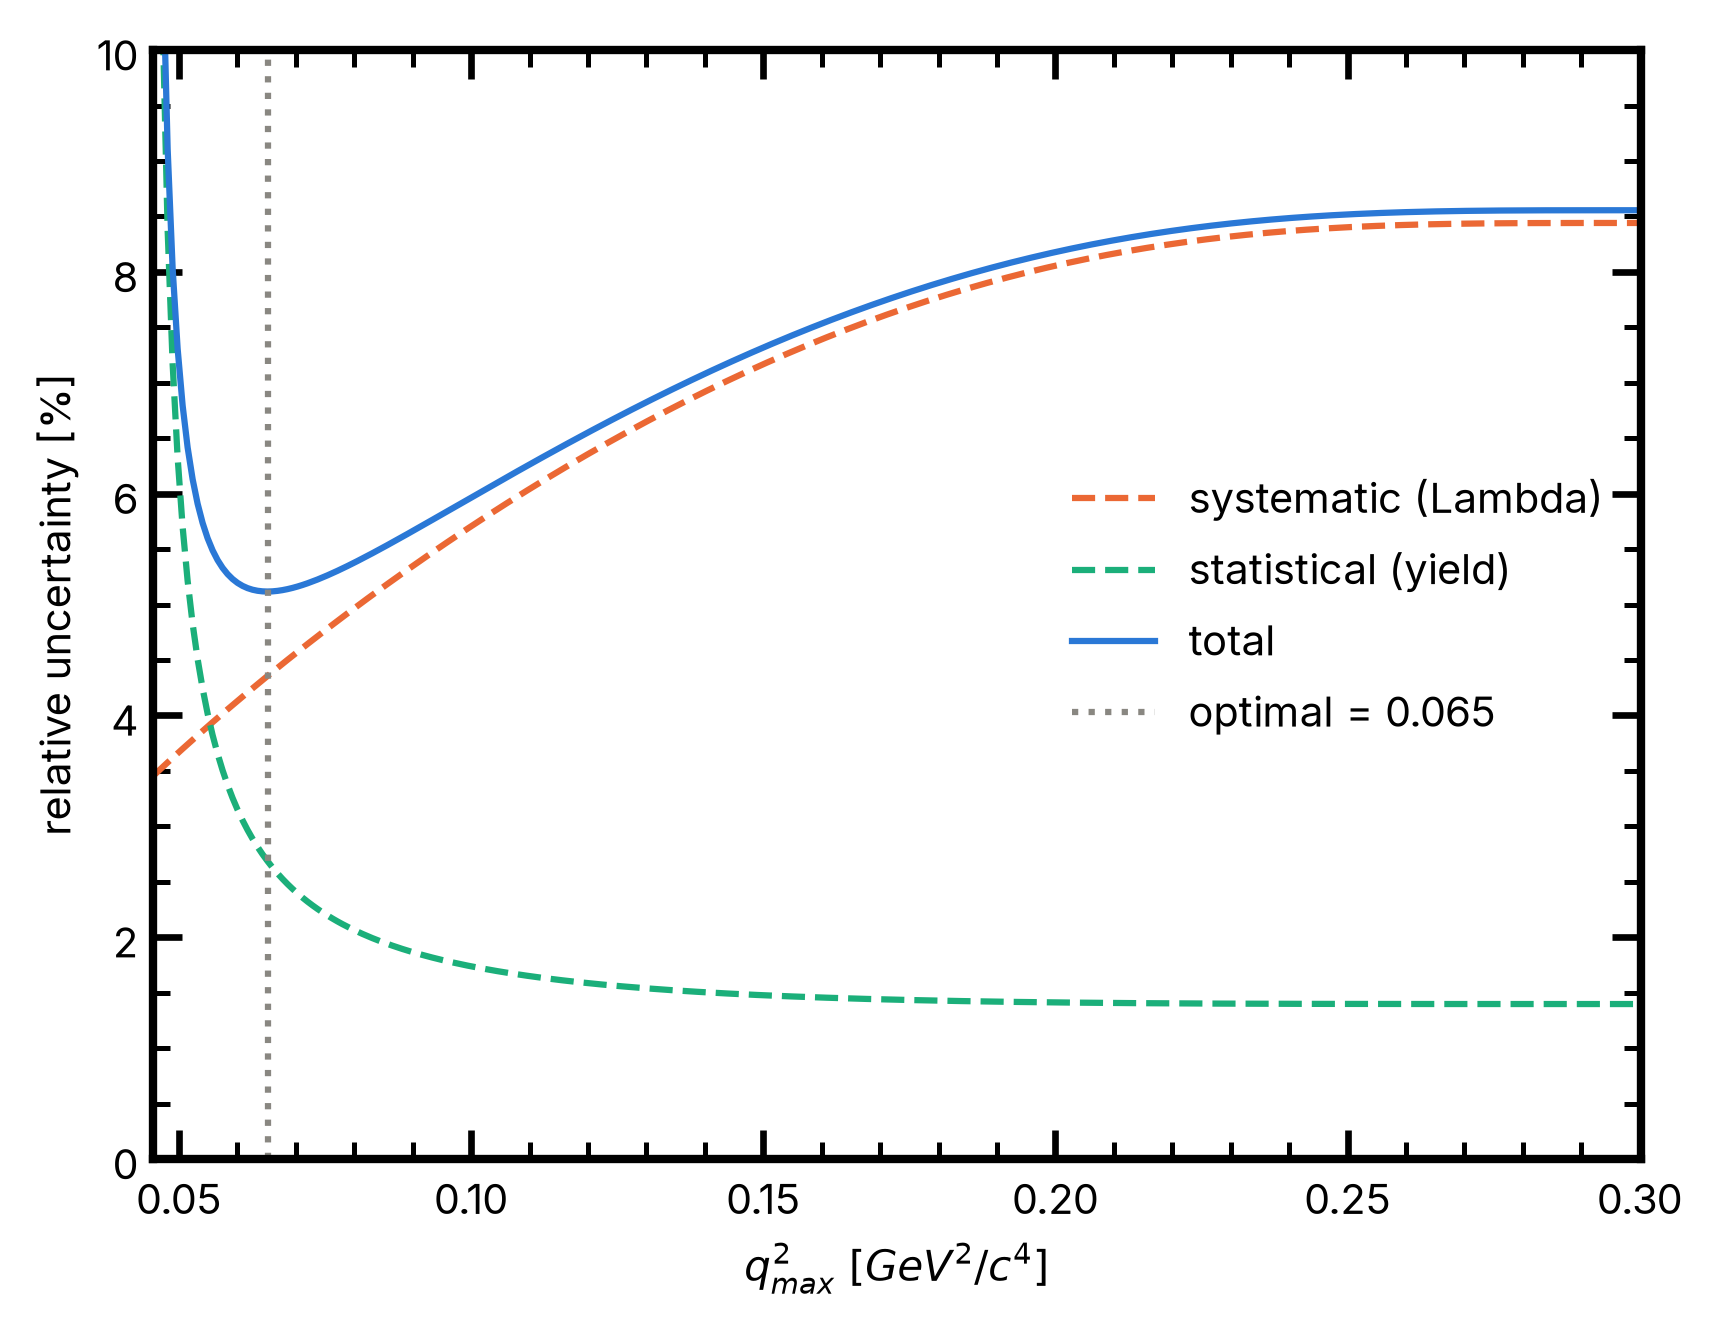

In [14]:
# Fitted eta -> mu+ mu- gamma signal yield (full q2 range), from a fit to data.
# NOTE: no 2025-specific signal yield has been supplied yet, so this reuses
# the 2016 (NA60) placeholder yield -- only the systematic (Lambda-driven)
# curve below reflects real 2025 numbers; the statistical (yield-driven) one
# is a placeholder pending real 2025 numbers.
N_SIG, DN_SIG = 223295, 3120  # signal candidates, full kinematic range (2016 placeholder)

# BR0, DBR0 defined in the constants cell above.
ff = FormFactor()

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

# Scan q2_max across the full physical kinematic range [q2_min, m_eta^2]
q2_max_values = np.linspace(ff.q2_min, ff.q2_max, 300)[1:]  # skip q2_min itself (br=0 there)

br_full, _ = ff.integrate(Lambda0)
br_full *= ff.prefactor

values = []  # [q2_max, syst_rel, stat_rel, total_rel, br, dbr, n_retained]
for q2_max in q2_max_values:
    bounds = [ff.q2_min, q2_max]

    I_o, _ = ff.integrate(Lambda0, bounds=bounds)
    I_p, _ = ff.integrate(Lambda_p, bounds=bounds)
    I_m, _ = ff.integrate(Lambda_m, bounds=bounds)

    br = ff.prefactor * I_o
    dbr = ff.prefactor * np.abs(I_p - I_m) / 2.0
    syst_rel = dbr / br if np.isfinite(br) and br != 0.0 else np.nan

    # Retained fraction of the full-range branching ratio -> retained signal
    # candidates -> statistical uncertainty. This assumes the fitted yield
    # scales with the retained q2 range the same way the branching ratio does
    # (i.e. background dilutes proportionally); a real per-bin yield fit would
    # be more precise than this global rescaling.
    frac = br / br_full
    n_retained = N_SIG * frac
    stat_rel = (DN_SIG / N_SIG) / np.sqrt(frac) if frac > 0 else np.nan

    total_rel = np.sqrt(syst_rel**2 + stat_rel**2)
    values.append([q2_max, syst_rel, stat_rel, total_rel, br, dbr, n_retained])

values = np.array(values)

best_idx = np.nanargmin(values[:, 3])
best_q2max, best_syst, best_stat, best_total, best_br, best_dbr, best_n = values[best_idx]
print(f"Optimal q2_max = {best_q2max:.4f} GeV^2/c^4")
print(f"  syst (Lambda) = {best_syst:.3%}, stat (yield) = {best_stat:.3%}, total = {best_total:.3%}")
print(f"  retained signal ~ {best_n:,.0f} of {N_SIG:,} ({best_n/N_SIG:.1%})")
print(f"  BR = {best_br*1e4:.3f}e-4, total unc = {best_total*best_br*1e4:.3f}e-4")

# Table across a coarser grid, for reference
rows = list(values[::20])
if not np.array_equal(rows[-1], values[-1]):
    rows.append(values[-1])
table = [[f"{q2:.4f}", f"{s:.3%}", f"{st:.3%}", f"{t:.3%}", f"{n:,.0f}"] for q2, s, st, t, br, dbr, n in rows]
print(tabulate(table, headers=['q2_max', 'syst (Lambda)', 'stat (yield)', 'total', 'N_retained'], tablefmt="github"))

# Plot: systematic, statistical, and total relative uncertainty vs q2_max.
# Note: y-axis is wider than the 2016 version's (0-10% vs 0-4%) since
# LAMBDA0's much larger relative uncertainty here (~10% vs ~2%) pushes both
# the systematic curve and the optimal point well above 4%.
plt.plot(values[:, 0], values[:, 1] * 100, '--', color=COLORS['tertiary'], label='systematic (Lambda)')
plt.plot(values[:, 0], values[:, 2] * 100, '--', color=COLORS['secondary'], label='statistical (yield)')
plt.plot(values[:, 0], values[:, 3] * 100, '-', color=COLORS['primary'], label='total')
plt.axvline(best_q2max, color=COLORS['reference'], linestyle=':', label=f'optimal = {best_q2max:.3f}')
plt.xlabel(r'$q^2_{max}\,\, [GeV^2/c^4]$')
plt.ylabel('relative uncertainty [%]')
ax = plt.gca()
ax.margins(x=0)
ax.set_ylim(0, 10)
plt.legend(frameon=False)
style_axes(ax)
plt.show()
